In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
df = pd.read_csv("dataset.csv")

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.drop(labels=['RowNumber', 'Surname', 'CustomerId'], axis=1, inplace=True)

In [5]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
df.isnull().sum()

CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB


In [8]:
df['Geography'].unique()

array(['France', 'Spain', 'Germany'], dtype=object)

<Axes: xlabel='Geography', ylabel='count'>

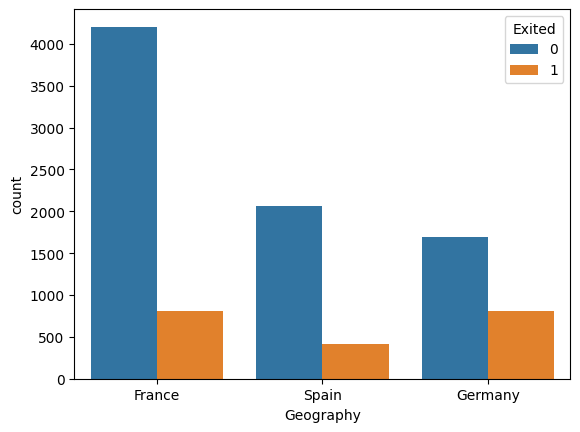

In [9]:
sns.countplot(data=df, x='Geography', hue='Exited')

<Axes: xlabel='Gender', ylabel='count'>

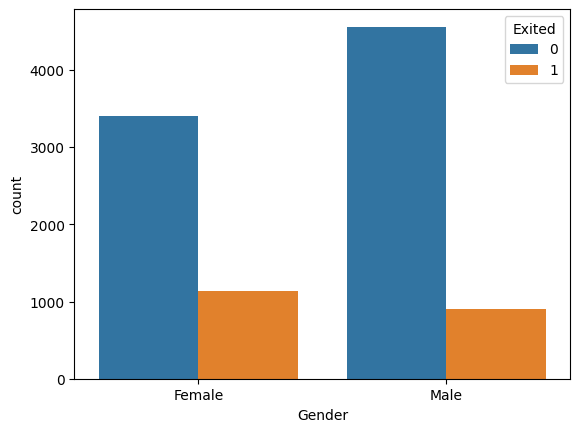

In [10]:
sns.countplot(data=df, x='Gender', hue='Exited')

In [11]:
df = pd.get_dummies(data=df, columns=['Geography', 'Gender'], drop_first=True)

df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


In [12]:
df['Tenure']

0        2
1        1
2        8
3        1
4        2
        ..
9995     5
9996    10
9997     7
9998     3
9999     4
Name: Tenure, Length: 10000, dtype: int64

In [13]:
df['NumOfProducts'].unique()

array([1, 3, 2, 4], dtype=int64)

In [14]:
cols = ['Tenure', 'CreditScore', 'Age', 'Balance', 'EstimatedSalary']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

In [15]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,-0.326221,0.293517,-1.041760,-1.225848,1,1,1,0.021886,1,False,False,False
1,-0.440036,0.198164,-1.387538,0.117350,1,0,1,0.216534,0,False,True,False
2,-1.536794,0.293517,1.032908,1.333053,3,1,0,0.240687,1,False,False,False
3,0.501521,0.007457,-1.387538,-1.225848,2,0,0,-0.108918,0,False,False,False
4,2.063884,0.388871,-1.041760,0.785728,1,1,1,-0.365276,0,False,True,False


In [16]:
## Devide the train test spilit

from sklearn.model_selection import train_test_split

In [17]:
X = df.drop(columns = ['Exited'])
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [18]:
print(X_train.shape)
print(y_train.shape)

(7000, 11)
(7000,)


In [19]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
from keras import Input

In [20]:
model = Sequential([
    Input(shape=(11,)),

    Dense(32, activation='relu'),
    Dense(13, activation='relu'),
    Dense(1, activation='sigmoid')
])


In [21]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(x=X_train, y=y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6588 - loss: 0.5933 - val_accuracy: 0.7979 - val_loss: 0.4385
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7991 - loss: 0.4385 - val_accuracy: 0.8171 - val_loss: 0.4211
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8142 - loss: 0.4292 - val_accuracy: 0.8214 - val_loss: 0.4165
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8195 - loss: 0.4141 - val_accuracy: 0.8236 - val_loss: 0.4100
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8204 - loss: 0.4124 - val_accuracy: 0.8293 - val_loss: 0.4052
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8349 - loss: 0.4048 - val_accuracy: 0.8286 - val_loss: 0.4001
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8351 - loss: 0.4015 - val_accuracy: 0.8371 - val_loss: 0.3953
Epoch 8/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8341 - loss: 0.4002 - val_accuracy: 0.

In [23]:
loss, accuracy = model.evaluate(X_test, y_test)

print(f"""Final Test Accuracy: {accuracy * 100:.2f}%
Final Test Loss: {loss:.2f}""")

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8607 - loss: 0.3406 
Final Test Accuracy: 86.60%
Final Test Loss: 0.34


In [24]:
y_pred = model.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [25]:
print(y_pred)

[[0.01954832]
 [0.01329398]
 [0.06053768]
 ...
 [0.02054643]
 [0.00322393]
 [0.10470489]]


In [26]:
y_pred = (y_pred>0.5).astype("int32")

In [27]:
print(y_pred)

[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]


In [28]:
print("Model Predictions:", y_pred[:15].flatten())
print("Actual Answers:   ", y_test[:15].values)

Model Predictions: [0 0 0 0 0 0 0 0 0 1 1 1 1 0 0]
Actual Answers:    [0 0 0 0 0 0 0 1 0 0 1 1 1 0 0]


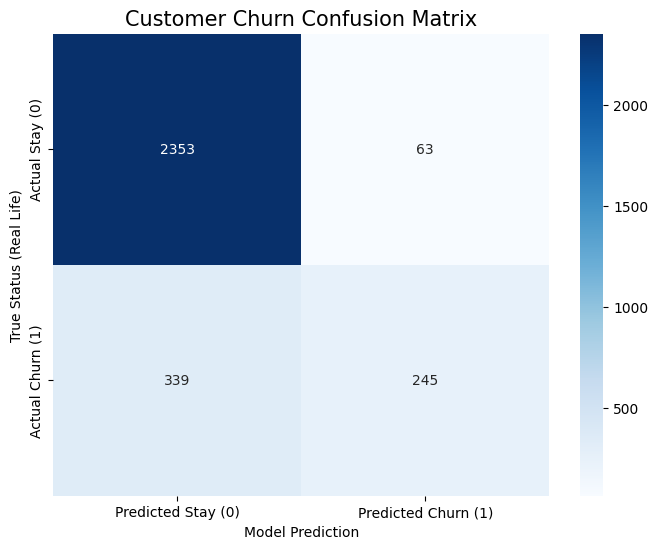

In [29]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate the raw matrix numbers
cm = confusion_matrix(y_test, y_pred)

# 2. Plot it nicely using Seaborn
plt.figure(figsize=(8, 6))
# fmt='d' ensures the numbers print as clean integers, not scientific notation
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Stay (0)', 'Predicted Churn (1)'],
            yticklabels=['Actual Stay (0)', 'Actual Churn (1)'])

plt.title('Customer Churn Confusion Matrix', fontsize=15)
plt.ylabel('True Status (Real Life)')
plt.xlabel('Model Prediction')
plt.show()

In [30]:
# Print the detailed statistical report
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2416
           1       0.80      0.42      0.55       584

    accuracy                           0.87      3000
   macro avg       0.83      0.70      0.74      3000
weighted avg       0.86      0.87      0.85      3000

